Note: This is the extended V2 implementation featuring LSTM. The accompanying report discusses an earlier RF/LightGBM version of the framework


🚀 Starting Multi-Factor Demand Forecasting Project (V2)
1️⃣ Fetching all data sources...
✅ All data sources loaded.

2️⃣ Integrating data and engineering features...
✅ Data integration and feature engineering complete.

3️⃣ Splitting data into training and test sets (chronological)...
   Train set size: 620 records
   Test set size: 110 records
✅ Data splitting complete.

4️⃣ Training Random Forest Regressor...
✅ Random Forest training complete.

5️⃣ Generating SHAP explanations for Random Forest...
✅ SHAP analysis complete.

   Displaying SHAP Summary Plot for Random Forest...


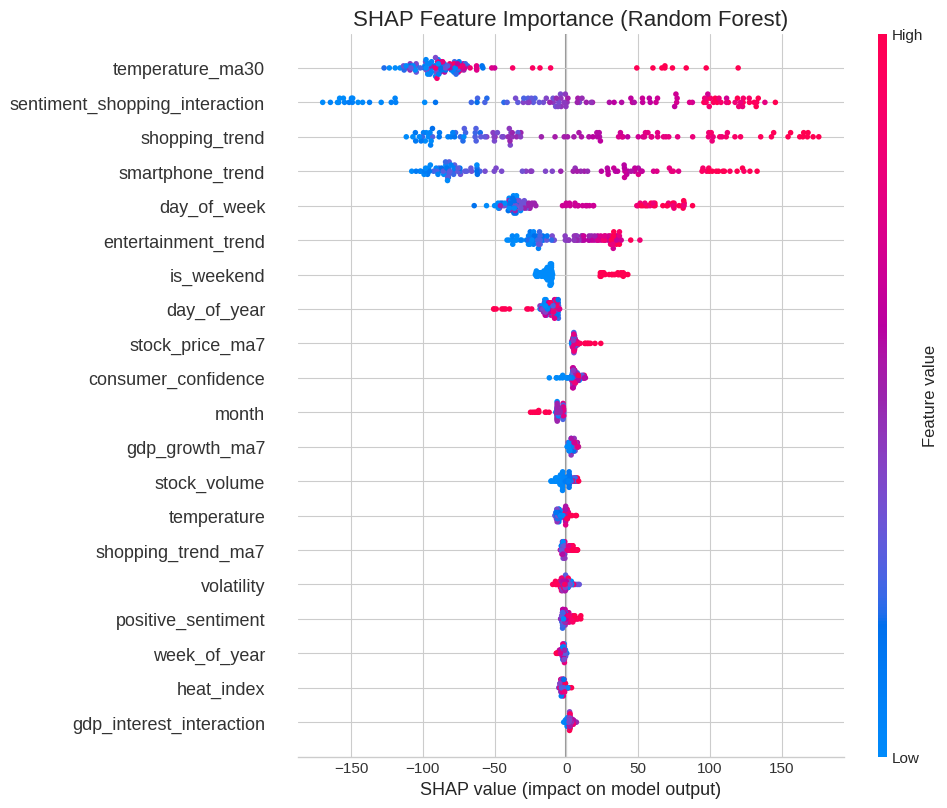


   Displaying SHAP Dependence Plots for top 2 features of Random Forest...


<Figure size 800x600 with 0 Axes>

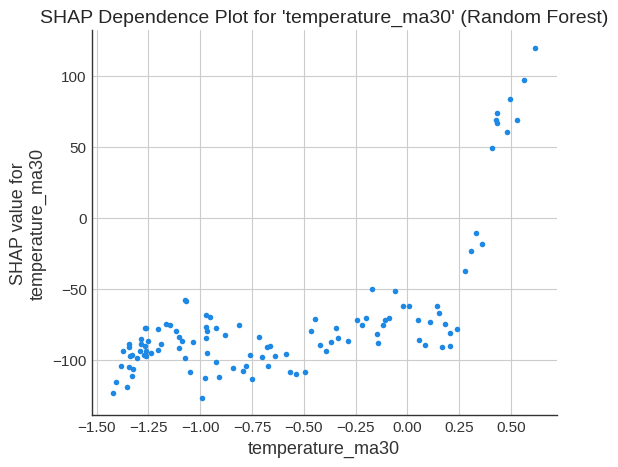

<Figure size 800x600 with 0 Axes>

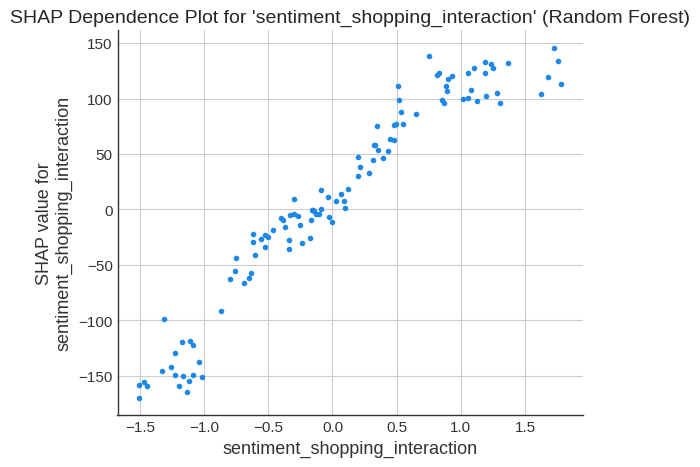


6️⃣ Preparing data and training LSTM model...
✅ LSTM training complete.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step

   Displaying LSTM Training and Validation Loss...


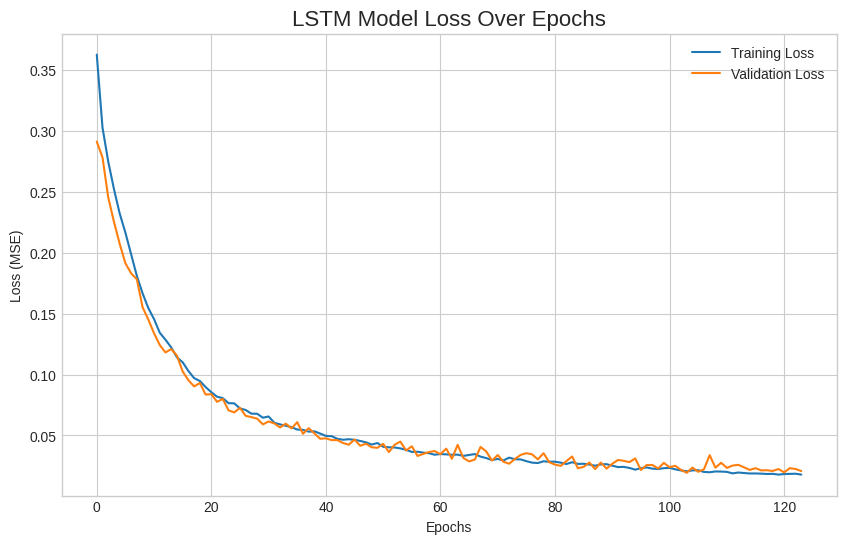


7️⃣ Generating SHAP explanations for LSTM...
   ⚠️ SHAP for LSTM failed: in user code:

    File "/usr/local/lib/python3.11/dist-packages/shap/explainers/_deep/deep_tf.py", line 265, in grad_graph  *
        x_grad = tape.gradient(out, shap_rAnD)

    LookupError: gradient registry has no entry for: shap_TensorListStack
. This can be due to TensorFlow/Keras version, model complexity, or specific layer types. Skipping LSTM SHAP plots.

8️⃣ Generating Final Model Performance and Factor Importance Comparison...

--- Model Performance Comparison (Random Forest vs. LSTM) ---
                       Metric Random Forest   LSTM
                     R² Score        0.5029 0.5419
    Mean Absolute Error (MAE)        119.76 119.50
Root Mean Square Error (RMSE)        153.07 146.94


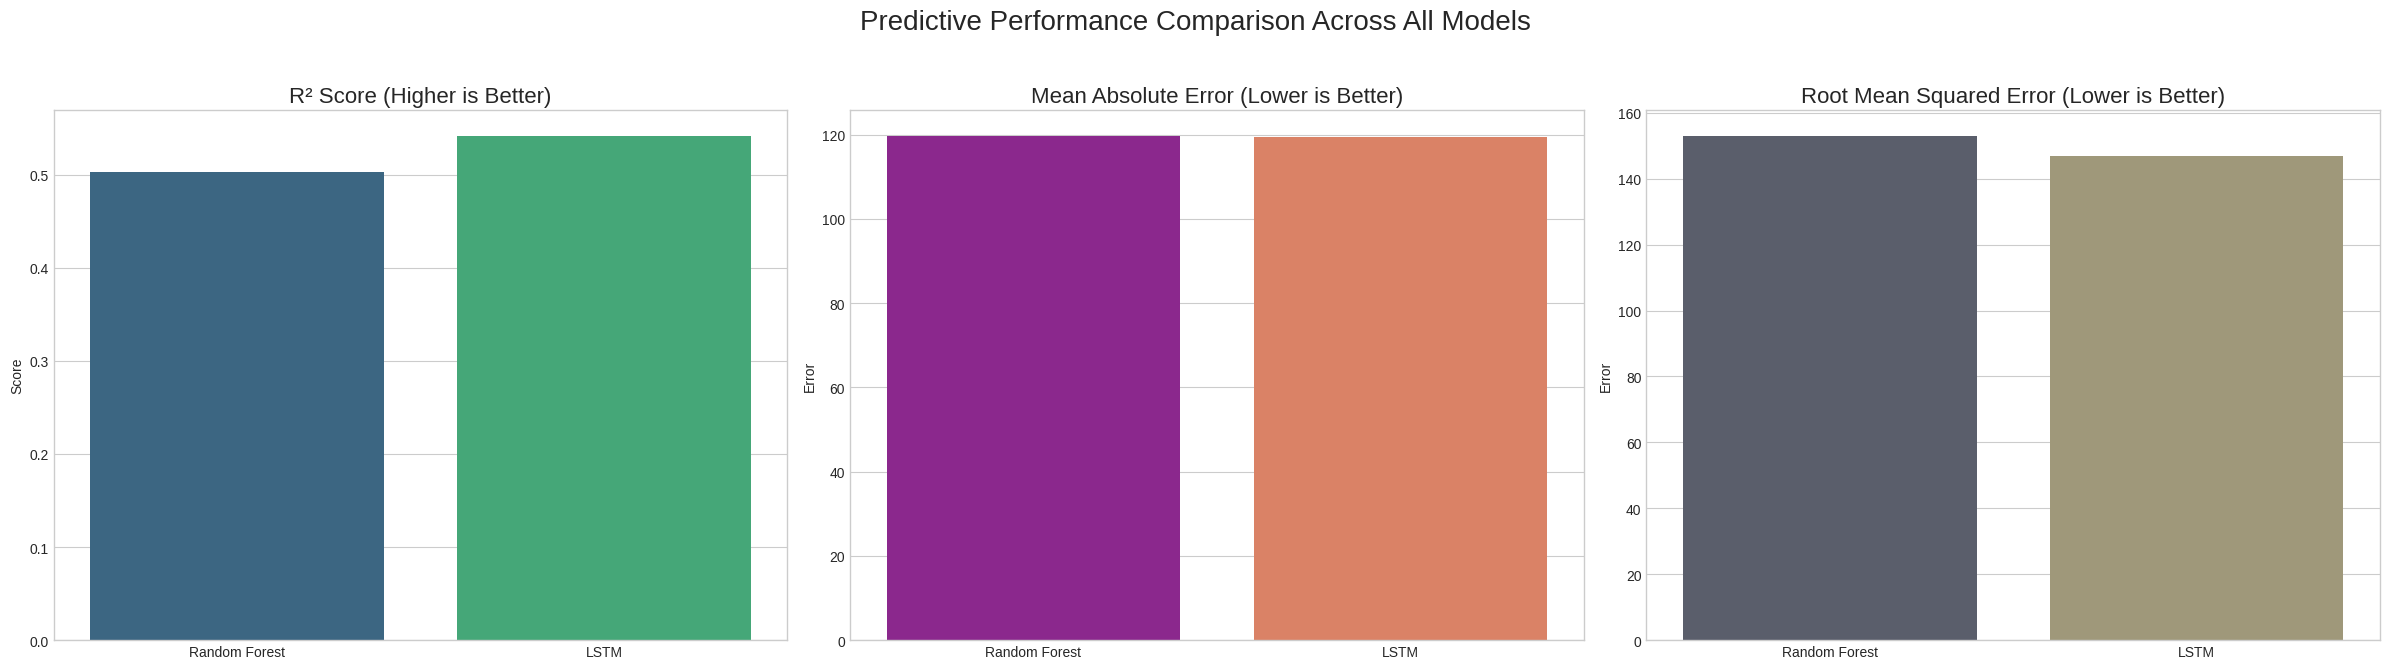

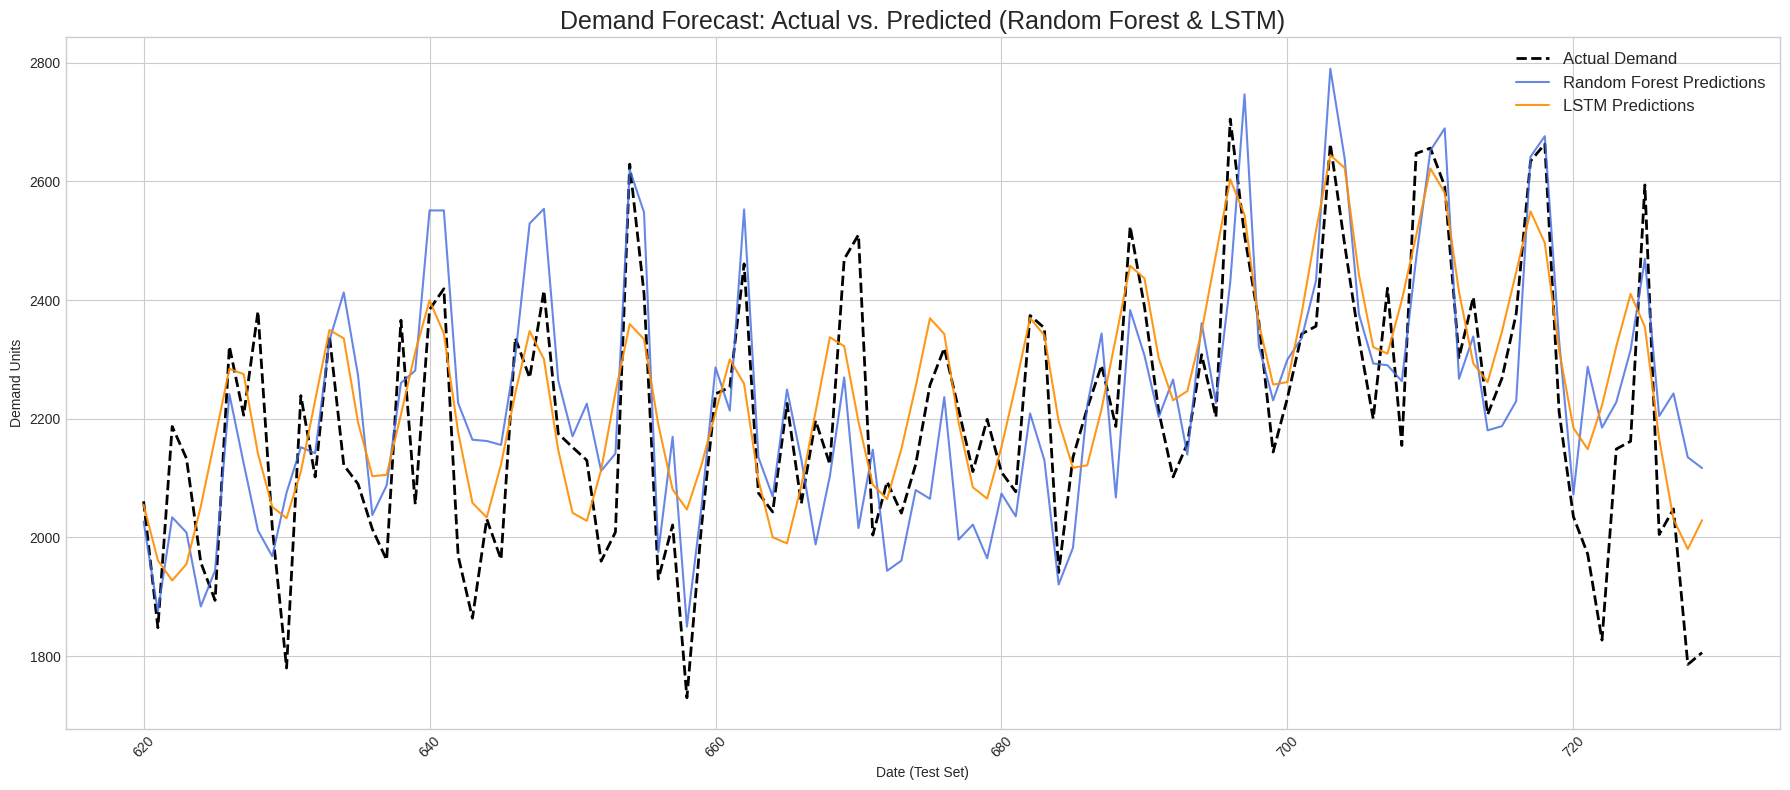


--- Factor Group Importance Comparison (Random Forest Default, SHAP-RF, SHAP-LSTM) ---

Note: SHAP for LSTM can be computationally intensive and interpretations differ based on model type.

   LSTM SHAP values not available for pie chart due to previous computation issues.


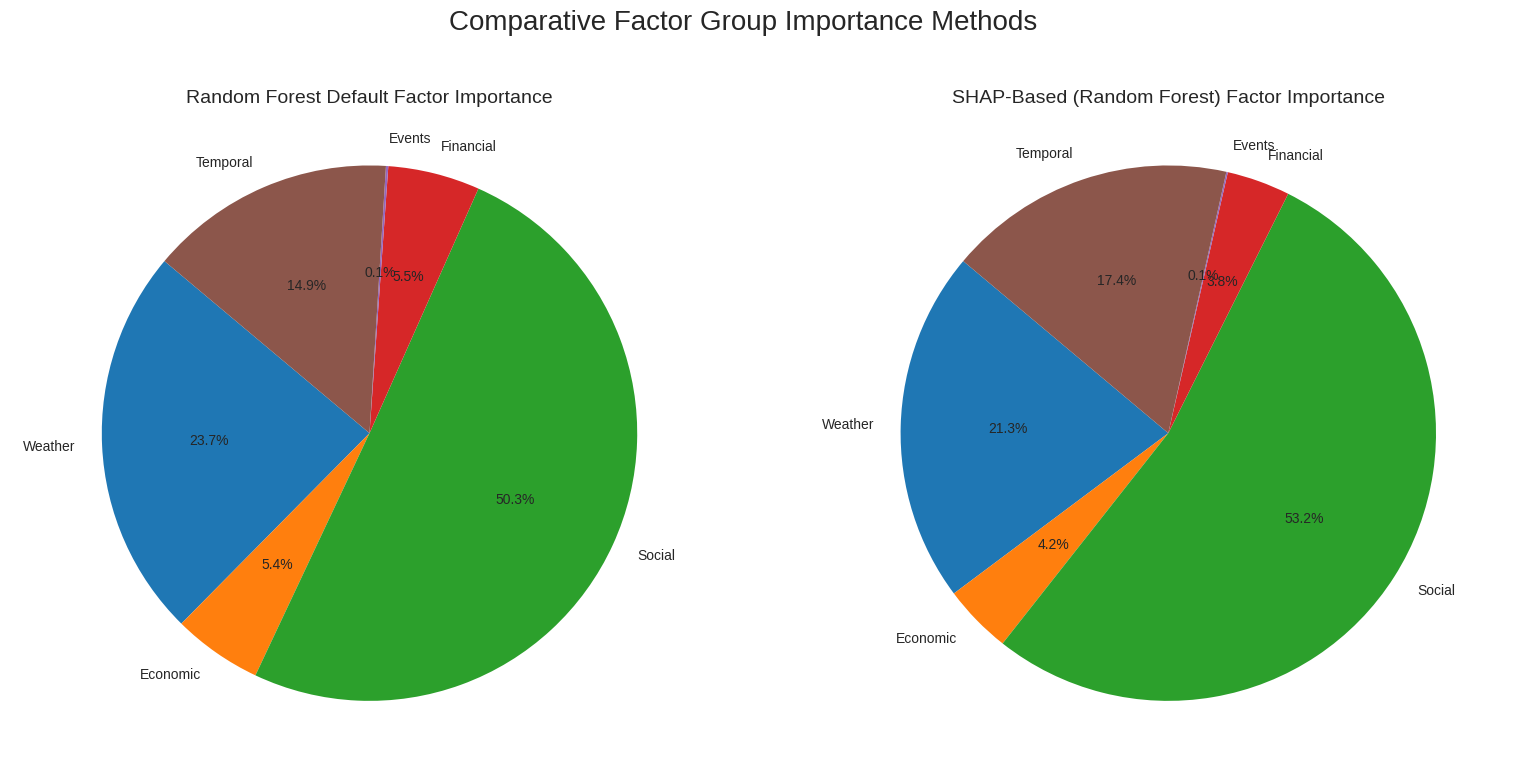


✅ Full comparison and analysis complete.


In [ ]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import time
import warnings
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# TensorFlow imports for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

# ==============================================================================
# 1. API KEYS & CONFIGURATION
# --- IMPORTANT: Replace with your actual keys if you have them ---
# If keys are not provided, the script will use realistic synthetic data.
# ==============================================================================
OPENWEATHER_API_KEY = ""
ALPHAVANTAGE_API_KEY = ""

# ==============================================================================
# 2. DATA FETCHING & GENERATION FUNCTIONS
# --- These functions fetch or generate the multi-factor data. ---
# ==============================================================================

def fetch_weather_data(api_key, city="Delhi,IN", days=365):
    """Fetch or generate comprehensive weather data."""
    if not api_key:
        print("   ⚠️ Weather API key missing, using synthetic data.")
        return generate_synthetic_weather(days)
    try:
        # Attempt to get current weather for realistic base values
        base_url = "http://api.openweathermap.org/data/2.5/weather"
        params = {'q': city, 'appid': api_key, 'units': 'metric'}
        response = requests.get(base_url, params=params, timeout=10)

        if response.status_code == 200:
            current_data = response.json()
            base_temp = current_data['main']['temp']
            base_humidity = current_data['main']['humidity']
            base_pressure = current_data['main']['pressure']
        else:
            print(f"   ⚠️ Weather API error ({response.status_code}), using synthetic data.")
            return generate_synthetic_weather(days)

        weather_data = []
        for i in range(days):
            date = datetime.now() - timedelta(days=i)
            day_of_year = date.timetuple().tm_yday

            # Seasonal temperature variation (more pronounced for Delhi)
            # Peak around May-June (day 150-180), low around Dec-Jan (day 350-30)
            seasonal_temp = 15 * np.sin(2 * np.pi * (day_of_year - 150) / 365)
            temp = base_temp + seasonal_temp + np.random.normal(0, 3) # Add random noise

            # Humidity and pressure variations
            humidity = max(20, min(90, base_humidity + np.random.normal(0, 8)))
            pressure = base_pressure + np.random.normal(0, 8)

            weather_data.append({
                'date': date.strftime('%Y-%m-%d'),
                'temperature': round(temp, 1),
                'humidity': round(humidity, 1),
                'pressure': round(pressure, 1),
                'feels_like': round(temp * 1.1 - humidity * 0.05 + np.random.normal(0, 2), 1) # More complex feels_like
            })
        return pd.DataFrame(weather_data).sort_values('date').reset_index(drop=True)

    except Exception as e:
        print(f"   ⚠️ Weather fetch error: {e}, using synthetic data.")
        return generate_synthetic_weather(days)

def generate_synthetic_weather(days=365):
    """Generate realistic synthetic weather data."""
    weather_data = []
    base_temp = 28  # Delhi average temperature

    for i in range(days):
        date = datetime.now() - timedelta(days=i)
        day_of_year = date.timetuple().tm_yday

        # Seasonal patterns for Delhi
        seasonal_temp = 12 * np.sin(2 * np.pi * (day_of_year - 80) / 365)
        temp = base_temp + seasonal_temp + np.random.normal(0, 4) # Add more noise

        weather_data.append({
            'date': date.strftime('%Y-%m-%d'),
            'temperature': round(temp, 1),
            'humidity': round(max(30, min(85, 60 + np.random.normal(0, 15))), 1),
            'pressure': round(1013 + np.random.normal(0, 10), 1),
            'feels_like': round(temp * 1.1 - 60 * 0.05 + np.random.normal(0, 3), 1)
        })
    return pd.DataFrame(weather_data).sort_values('date').reset_index(drop=True)

def fetch_economic_data(days=365):
    """Generate comprehensive economic indicators."""
    dates = pd.date_range(end=datetime.now(), periods=days, freq='D')
    economic_data = []

    # Base values for India (approximate real values)
    base_gdp = 6.8
    base_inflation = 4.5
    base_unemployment = 8.1
    base_interest_rate = 6.5

    for i, date in enumerate(dates):
        # Simulate gentle economic cycles and trends
        cycle_long = i / 90
        cycle_short = i / 30

        gdp_growth = base_gdp + 0.5 * np.sin(cycle_long) + np.random.normal(0, 0.2)
        inflation = base_inflation + 0.3 * np.cos(cycle_short/2) + np.random.normal(0, 0.1)
        unemployment = base_unemployment - 0.2 * np.sin(cycle_long) + np.random.normal(0, 0.1)
        interest_rate = base_interest_rate + 0.1 * np.sin(cycle_long/3) + np.random.normal(0, 0.05)

        # Consumer confidence often correlates with economic health
        consumer_confidence = 50 + 20 * np.sin(cycle_long + np.pi/2) + np.random.normal(0, 5)

        economic_data.append({
            'date': date.strftime('%Y-%m-%d'),
            'gdp_growth': round(max(0, gdp_growth), 2),
            'inflation_rate': round(max(0, inflation), 2),
            'unemployment_rate': round(max(0, unemployment), 2),
            'interest_rate': round(max(0, interest_rate), 2),
            'consumer_confidence': round(max(0, min(100, consumer_confidence)), 1)
        })
    return pd.DataFrame(economic_data).sort_values('date').reset_index(drop=True)

def fetch_social_trends(days=365):
    """Generate social media sentiment and trends data."""
    dates = pd.date_range(end=datetime.now(), periods=days, freq='D')
    trends_data = []

    for i, date in enumerate(dates):
        day_of_week = date.weekday()

        # Weekend vs weekday patterns (more engagement on weekends)
        weekend_boost = 1.3 if day_of_week >= 5 else 1.0

        # Simulate various trending topics with seasonal/cyclical patterns
        smartphone_trend = (45 + 25 * np.sin(i/15) + np.random.normal(0, 8)) * weekend_boost
        shopping_trend = (40 + 30 * np.sin(i/10) + np.random.normal(0, 10)) * weekend_boost
        entertainment_trend = (35 + 35 * np.sin(i/7) + np.random.normal(0, 12)) * weekend_boost

        # Sentiment analysis simulation (positive dominant, some negative/neutral)
        positive_sentiment = max(0, min(100, 60 + np.random.normal(0, 15)))
        negative_sentiment = max(0, min(100, 25 + np.random.normal(0, 10)))
        neutral_sentiment = 100 - positive_sentiment - negative_sentiment
        neutral_sentiment = max(0, neutral_sentiment)

        # Social engagement score (random fluctuations around a base)
        social_engagement_score = 50 + np.random.normal(0, 15)

        trends_data.append({
            'date': date.strftime('%Y-%m-%d'),
            'smartphone_trend': round(max(0, min(100, smartphone_trend)), 1),
            'shopping_trend': round(max(0, min(100, shopping_trend)), 1),
            'entertainment_trend': round(max(0, min(100, entertainment_trend)), 1),
            'positive_sentiment': round(positive_sentiment, 1),
            'negative_sentiment': round(negative_sentiment, 1),
            'social_engagement_score': round(social_engagement_score, 1)
        })
    return pd.DataFrame(trends_data).sort_values('date').reset_index(drop=True)

def fetch_holidays_data_with_library(country='IN'):
    """Fetch holidays using Python holidays library."""
    current_year = datetime.now().year
    # Include previous and next year to ensure full coverage for any date range
    years = [current_year - 1, current_year, current_year + 1]
    india_holidays = holidays.India(years=years)

    holidays_data = []
    for date_obj, holiday_name in india_holidays.items():
        is_national = any(k in holiday_name.lower() for k in ['independence', 'republic', 'gandhi', 'labour'])
        is_religious = any(k in holiday_name.lower() for k in ['diwali', 'holi', 'eid', 'christmas', 'dussehra', 'guru', 'janmashtami', 'navratri', 'karva'])
        holidays_data.append({
            'date': date_obj.strftime('%Y-%m-%d'),
            'is_national': is_national,
            'is_religious': is_religious
        })
    df = pd.DataFrame(holidays_data).drop_duplicates(subset=['date']).sort_values('date')
    return df

def fetch_financial_data(api_key, days=365):
    """Fetch or generate comprehensive financial market data."""
    if not api_key:
        print("   ⚠️ Financial API key missing, using synthetic data.")
        return generate_synthetic_financial(days)
    try:
        # Using Reliance Industries Ltd (RELIANCE.BSE) as a proxy for Indian market
        url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=RELIANCE.BSE&apikey={api_key}&outputsize=full"
        response = requests.get(url, timeout=20)

        if response.status_code == 200 and 'Time Series (Daily)' in response.json():
            time_series = response.json()['Time Series (Daily)']
            financial_data = []

            # Fetch up to 'days' records, ensuring we don't go out of bounds of available data
            count = 0
            for date_str, values in time_series.items():
                if count >= days:
                    break
                financial_data.append({
                    'date': date_str,
                    'stock_price': float(values['4. close']),
                    'stock_volume': int(float(values['5. volume'])),
                    'stock_high': float(values['2. high']),
                    'stock_low': float(values['3. low']),
                    'stock_open': float(values['1. open'])
                })
                count += 1

            df = pd.DataFrame(financial_data)
            df['price_change'] = df['stock_price'].pct_change() * 100
            df['volatility'] = df['price_change'].rolling(window=7).std()
            return df.fillna(0).sort_values('date').reset_index(drop=True)
        else:
            print(f"   ⚠️ Financial API error, using synthetic data. Response: {response.json().get('Note', response.status_code)}")
            return generate_synthetic_financial(days)
    except Exception as e:
        print(f"   ⚠️ Financial fetch error: {e}, using synthetic data.")
        return generate_synthetic_financial(days)

def generate_synthetic_financial(days=365):
    """Generate realistic synthetic financial market data."""
    dates = pd.date_range(end=datetime.now(), periods=days, freq='D')
    financial_data = []

    # Start with a realistic base price for Reliance (approximate)
    price = 2800

    for date in dates:
        # Simulate realistic daily returns and price movement with some trend
        daily_return = np.random.normal(0.0003, 0.025)
        price *= (1 + daily_return)

        # Volume with some correlation to price movement (higher volume on big moves)
        base_volume = 1500000
        volume_factor = 1 + abs(daily_return) * 2
        volume = int(base_volume * volume_factor * (1 + np.random.normal(0, 0.3)))

        financial_data.append({
            'date': date.strftime('%Y-%m-%d'),
            'stock_price': round(price, 2),
            'stock_volume': max(100000, volume),
            'stock_high': round(price * (1 + abs(np.random.normal(0, 0.01))), 2),
            'stock_low': round(price * (1 - abs(np.random.normal(0, 0.01))), 2),
            'stock_open': round(price * (1 + np.random.normal(0, 0.005)), 2)
        })
    df = pd.DataFrame(financial_data)
    df['price_change'] = df['stock_price'].pct_change() * 100
    df['volatility'] = df['price_change'].rolling(window=7).std()
    return df.fillna(0).sort_values('date').reset_index(drop=True)


# ==============================================================================
# 3. FEATURE ENGINEERING & DEMAND GENERATION
# ==============================================================================
def create_comprehensive_features(df):
    """Create advanced time-based, rolling, and interaction features."""
    df = df.copy()

    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

    # Rolling averages for trends
    for col in ['temperature', 'stock_price', 'shopping_trend', 'positive_sentiment', 'gdp_growth']:
        if col in df.columns:
            df[f'{col}_ma7'] = df[col].rolling(window=7, min_periods=1).mean()
            df[f'{col}_ma30'] = df[col].rolling(window=30, min_periods=1).mean()
            # Add lag features for time series
            df[f'{col}_lag1'] = df[col].shift(1)
            df[f'{col}_lag7'] = df[col].shift(7)

    # Interaction features
    if 'temperature' in df.columns and 'humidity' in df.columns:
        df['heat_index'] = df['temperature'] * 1.07 - (df['humidity'] * 0.05)
        df['temp_humidity_interaction'] = df['temperature'] * df['humidity'] / 100

    if 'positive_sentiment' in df.columns and 'shopping_trend' in df.columns:
        df['sentiment_shopping_interaction'] = df['positive_sentiment'] * df['shopping_trend'] / 100

    if 'gdp_growth' in df.columns and 'interest_rate' in df.columns:
        df['gdp_interest_interaction'] = df['gdp_growth'] * df['interest_rate']

    # Ensure all NaN values from shift/rolling operations are handled
    df.fillna(df.mean(numeric_only=True), inplace=True)

    return df

def generate_realistic_demand(df):
    """Generate a realistic demand target variable based on multiple factors."""
    np.random.seed(42)

    demands = []
    base_demand = 1500

    for idx, row in df.iterrows():
        demand = base_demand

        # Weather impact
        temp = row.get('temperature', 25)
        if temp > 35:
            demand += (temp - 35) * 20
        elif temp < 15:
            demand += (15 - temp) * 15
        else:
            demand += (temp - 25) * 5

        humidity_impact = (row.get('humidity', 50) - 50) * 1.0
        demand += humidity_impact

        # Economic factors
        gdp_growth = row.get('gdp_growth', 6)
        demand += gdp_growth * 40

        inflation = row.get('inflation_rate', 4)
        demand -= inflation * 25

        unemployment = row.get('unemployment_rate', 8)
        demand -= unemployment * 20

        consumer_confidence = row.get('consumer_confidence', 70)
        demand += (consumer_confidence - 50) * 4

        # Social trends
        shopping_trend = row.get('shopping_trend', 50)
        smartphone_trend = row.get('smartphone_trend', 50)
        entertainment_trend = row.get('entertainment_trend', 50)

        demand += shopping_trend * 6
        demand += smartphone_trend * 4
        demand += entertainment_trend * 2

# Sentiment impact
        positive_sentiment = row.get('positive_sentiment', 60)
        demand += (positive_sentiment - 50) * 3

        # Financial market impact
        stock_price = row.get('stock_price', 2800)
        demand += (stock_price - 2800) * 0.05
        volatility = row.get('volatility', 1.0)
        demand -= volatility * 10

        # Holiday effects
        if row.get('is_holiday', 0):
            if row.get('is_national', False):
                demand += 500
            else:
                demand += 250

        # Temporal patterns
        day_of_week = row.get('day_of_week', 3)
        if day_of_week == 5:
            demand += 200
        elif day_of_week == 6:
            demand += 150
        elif day_of_week == 4:
            demand += 100

        month = row.get('month', 6)
        # Strong seasonal boosts for Indian festivals
        if month in [9, 10, 11]:
            demand += 300
        elif month in [1, 2]:
            demand += 100
        elif month in [5, 6]:
            demand += 80

        # Add realistic noise to simulate unpredictable factors
        demand += np.random.normal(0, 75)

        # Ensure minimum demand and round
        demand = max(500, demand)
        demands.append(round(demand))
    return demands

# ==============================================================================
# 4. ENHANCED LSTM DATA PREPARATION
# ==============================================================================
def create_lstm_sequences(data, target_col, feature_cols, time_steps=14):
    """
    Creates sequences of data for LSTM model training.
    """
    X, y = [], []
    data = data.reset_index(drop=True)

    for i in range(len(data) - time_steps):
        X.append(data.loc[i:(i + time_steps - 1), feature_cols].values)
        y.append(data.loc[i + time_steps, target_col])

    return np.array(X), np.array(y)

# ==============================================================================
# 5. MAIN EXECUTION SCRIPT
# ==============================================================================
if __name__ == "__main__":
    print("\n🚀 Starting Multi-Factor Demand Forecasting Project (V2)")
    print("=" * 60)

    # --- Data Collection ---
    print("1️⃣ Fetching all data sources...")
    data_days = 730
    weather_df = fetch_weather_data(OPENWEATHER_API_KEY, days=data_days)
    economic_df = fetch_economic_data(days=data_days)
    trends_df = fetch_social_trends(days=data_days)
    holidays_df = fetch_holidays_data_with_library()
    financial_df = fetch_financial_data(ALPHAVANTAGE_API_KEY, days=data_days)
    print("✅ All data sources loaded.")

    # --- Data Integration and Preprocessing ---
    print("\n2️⃣ Integrating data and engineering features...")
    main_df = weather_df.merge(economic_df, on='date', how='left')
    main_df = main_df.merge(trends_df, on='date', how='left')
    main_df = main_df.merge(financial_df, on='date', how='left')

    main_df['date'] = pd.to_datetime(main_df['date'])
    holidays_df['date'] = pd.to_datetime(holidays_df['date'])

    main_df = main_df.merge(holidays_df, on='date', how='left')
    main_df['is_holiday'] = (~main_df['is_national'].isna()).astype(int)
    main_df['is_national'] = main_df['is_national'].fillna(False).astype(int)
    main_df['is_religious'] = main_df['is_religious'].fillna(False).astype(int)

    main_df = main_df.fillna(method='ffill').fillna(method='bfill')

    main_df = create_comprehensive_features(main_df)

    main_df['demand'] = generate_realistic_demand(main_df)

    main_df = main_df.sort_values('date').reset_index(drop=True)
    print("✅ Data integration and feature engineering complete.")

    # --- Feature Selection ---
    feature_cols = [
        # Weather
        'temperature', 'humidity', 'pressure', 'feels_like', 'heat_index',
        'temperature_ma7', 'temperature_ma30', 'temperature_lag1', 'temperature_lag7',
        'temp_humidity_interaction',
        # Economic
        'gdp_growth', 'inflation_rate', 'unemployment_rate', 'interest_rate', 'consumer_confidence',
        'gdp_growth_ma7', 'gdp_growth_lag1', 'gdp_interest_interaction',
        # Social
        'smartphone_trend', 'shopping_trend', 'entertainment_trend', 'positive_sentiment', 'social_engagement_score',
        'sentiment_shopping_interaction', 'shopping_trend_ma7', 'shopping_trend_lag1', 'positive_sentiment_ma7', 'positive_sentiment_lag1',
        # Financial
        'stock_price', 'stock_volume', 'stock_high', 'stock_low', 'stock_open', 'price_change', 'volatility',
        'stock_price_ma7', 'stock_price_lag1',
        # Events
        'is_holiday', 'is_national', 'is_religious',
        # Temporal
        'month', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend', 'week_of_year'
    ]

    available_features = [col for col in feature_cols if col in main_df.columns]

    main_df = main_df.fillna(method='ffill').fillna(method='bfill')

    X = main_df[available_features]
    y = main_df['demand']

    # --- Data Splitting (Strict Chronological Split for all models) ---
    print("\n3️⃣ Splitting data into training and test sets (chronological)...")
    train_size = int(len(X) * 0.85)

    X_train_rf, X_test_rf = X.iloc[:train_size], X.iloc[train_size:]
    y_train_rf, y_test_rf = y.iloc[:train_size], y.iloc[train_size:]

    # Scale features for Random Forest
    scaler_rf = StandardScaler()
    X_train_scaled_rf = scaler_rf.fit_transform(X_train_rf)
    X_test_scaled_rf = scaler_rf.transform(X_test_rf)

    X_test_scaled_rf_df = pd.DataFrame(X_test_scaled_rf, columns=available_features, index=X_test_rf.index)
    print(f"   Train set size: {len(X_train_rf)} records")
    print(f"   Test set size: {len(X_test_rf)} records")
    print("✅ Data splitting complete.")

    # ==========================================================================
    # 🤖 MODEL 1: RANDOM FOREST REGRESSOR
    # ==========================================================================
    print("\n4️⃣ Training Random Forest Regressor...")
    rf_model = RandomForestRegressor(n_estimators=150, max_depth=12, min_samples_split=5,
                                          min_samples_leaf=3, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_scaled_rf, y_train_rf)
    y_pred_rf = rf_model.predict(X_test_scaled_rf)
    print("✅ Random Forest training complete.")

    # --- Performance Metrics for Random Forest ---
    mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
    r2_rf = r2_score(y_test_rf, y_pred_rf)


    # ==========================================================================
    # 🧠 SHAP EXPLANATION (Applied to the trained RF Model)
    # ==========================================================================
    print("\n5️⃣ Generating SHAP explanations for Random Forest...")
    explainer_rf_shap = shap.TreeExplainer(rf_model)
    shap_values_rf = explainer_rf_shap.shap_values(X_test_scaled_rf_df)
    print("✅ SHAP analysis complete.")

    # --- SHAP Summary Plot (Global Feature Importance) ---
    print("\n   Displaying SHAP Summary Plot for Random Forest...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_rf, X_test_scaled_rf_df, show=False, plot_size=[10, 8])
    plt.title("SHAP Feature Importance (Random Forest)", fontsize=16)
    plt.show()

    # --- SHAP Dependence Plots (Individual Feature Impact) ---
    print("\n   Displaying SHAP Dependence Plots for top 2 features of Random Forest...")
    top_features_shap_rf = pd.Series(np.abs(shap_values_rf).mean(0), index=available_features).nlargest(2).index
    for feature in top_features_shap_rf:
        plt.figure(figsize=(8, 6))
        shap.dependence_plot(feature, shap_values_rf, X_test_scaled_rf_df, interaction_index=None, show=False)
        plt.title(f"SHAP Dependence Plot for '{feature}' (Random Forest)", fontsize=14)
        plt.show()


    # ==========================================================================
    # 🧠 MODEL 2: LSTM NETWORK
    # ==========================================================================
    print("\n6️⃣ Preparing data and training LSTM model...")

    # --- Scaling for LSTM ---
    scaler_features_lstm = MinMaxScaler(feature_range=(0, 1))
    scaler_demand_lstm = MinMaxScaler(feature_range=(0, 1))

    lstm_data_scaled = main_df[available_features + ['demand']].copy()

    lstm_data_scaled.loc[:train_size-1, available_features] = scaler_features_lstm.fit_transform(lstm_data_scaled.loc[:train_size-1, available_features])
    lstm_data_scaled.loc[:train_size-1, 'demand'] = scaler_demand_lstm.fit_transform(lstm_data_scaled.loc[:train_size-1, ['demand']])

    lstm_data_scaled.loc[train_size:, available_features] = scaler_features_lstm.transform(lstm_data_scaled.loc[train_size:, available_features])
    lstm_data_scaled.loc[train_size:, 'demand'] = scaler_demand_lstm.transform(lstm_data_scaled.loc[train_size:, ['demand']])


    # --- Prepare sequences for LSTM ---
    TIME_STEPS = 30

    train_df_lstm = lstm_data_scaled.iloc[:train_size]
    test_df_lstm = lstm_data_scaled.iloc[train_size - TIME_STEPS:]

    X_train_lstm, y_train_lstm = create_lstm_sequences(train_df_lstm, 'demand', available_features, TIME_STEPS)
    X_test_lstm, y_test_lstm = create_lstm_sequences(test_df_lstm, 'demand', available_features, TIME_STEPS)

    # --- Build LSTM Model ---
    lstm_model = Sequential([
        LSTM(units=150, activation='tanh', return_sequences=True,
             input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
             kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        LSTM(units=75, activation='tanh', kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(units=40, activation='relu'),
        Dense(units=1)
    ])

    optimizer = Adam(learning_rate=0.0008)
    lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')

    # --- Train LSTM Model ---
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=0.00005, verbose=0)

    history = lstm_model.fit(
        X_train_lstm, y_train_lstm,
        epochs=200,
        batch_size=64,
        validation_data=(X_test_lstm, y_test_lstm),
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    print("✅ LSTM training complete.")

    # --- Inverse transform the predictions and actuals to original scale ---
    y_pred_lstm_scaled = lstm_model.predict(X_test_lstm).flatten()
    y_pred_lstm = scaler_demand_lstm.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()
    y_test_lstm_orig = scaler_demand_lstm.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

    # --- Performance Metrics for LSTM ---
    mae_lstm = mean_absolute_error(y_test_lstm_orig, y_pred_lstm)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_orig, y_pred_lstm))
    r2_lstm = r2_score(y_test_lstm_orig, y_pred_lstm)

    # --- Plot LSTM Training History (Loss Curve) ---
    print("\n   Displaying LSTM Training and Validation Loss...")
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('LSTM Model Loss Over Epochs', fontsize=16)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

    # ==========================================================================
    # 🧠 SHAP EXPLANATION (Applied to the LSTM Model)
    # ==========================================================================
    print("\n7️⃣ Generating SHAP explanations for LSTM...")
    # For DeepExplainer, you need a background dataset (e.g., a few samples from X_train_lstm)
    # and the model. It also needs the output shape to be (None, num_features) if model is sequential.
    # We take a small background dataset for performance
    background_lstm = X_train_lstm[np.random.choice(X_train_lstm.shape[0], 100, replace=False)]

    # DeepExplainer is for deep learning models.
    # It requires the input and output layers to be defined correctly.
    # If the model has multiple outputs or complex layers, it might need more specific setup.
    try:
        explainer_lstm_shap = shap.DeepExplainer(lstm_model, background_lstm)
        # Compute SHAP values for the LSTM test set
        # This can be very slow for large X_test_lstm and large models.
        # Consider sampling X_test_lstm for shap_values_lstm if needed (e.g., X_test_lstm[:500])
        shap_values_lstm = explainer_lstm_shap.shap_values(X_test_lstm)

        # DeepExplainer can return a list of arrays if the model has multiple outputs.
        # For a single output (regression), it often returns a single array or a list with one array.
        # Ensure shap_values_lstm is a single NumPy array for subsequent processing.
        if isinstance(shap_values_lstm, list):
            shap_values_lstm = shap_values_lstm[0] # Assuming single output regression

        print("✅ SHAP analysis for LSTM complete.")

    except Exception as e:
        print(f"   ⚠️ SHAP for LSTM failed: {e}. This can be due to TensorFlow/Keras version, model complexity, or specific layer types. Skipping LSTM SHAP plots.")
        shap_values_lstm = None # Set to None if computation fails

    # ==========================================================================
    # 8. FINAL MODEL PERFORMANCE & FACTOR IMPORTANCE ANALYSIS
    # ==========================================================================
    print("\n8️⃣ Generating Final Model Performance and Factor Importance Comparison...\n")

    # --- Comparison Table for Predictive Metrics ---
    # Note: SHAP RF performance is identical to Random Forest as it's the same model.
    comparison_data = {
        'Metric': ['R² Score', 'Mean Absolute Error (MAE)', 'Root Mean Square Error (RMSE)'],
        'Random Forest': [f"{r2_rf:.4f}", f"{mae_rf:.2f}", f"{rmse_rf:.2f}"],
        'LSTM': [f"{r2_lstm:.4f}", f"{mae_lstm:.2f}", f"{rmse_lstm:.2f}"]
    }
    comparison_df = pd.DataFrame(comparison_data)
    print("--- Model Performance Comparison (Random Forest vs. LSTM) ---")
    print(comparison_df.to_string(index=False))

    # --- Comparison Bar Charts for Predictive Metrics ---
    # Model names include SHAP RF for explicit visual representation, though values are identical to RF.
    metrics_to_plot = {
        'R² Score (Higher is Better)': [r2_rf, r2_lstm],
        'MAE (Lower is Better)': [mae_rf, mae_lstm],
        'RMSE (Lower is Better)': [rmse_rf, rmse_lstm]
    }
    model_labels = ['Random Forest', 'LSTM']

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    fig.suptitle('Predictive Performance Comparison Across All Models', fontsize=20)

    # R² Score Plot
    sns.barplot(x=model_labels, y=metrics_to_plot['R² Score (Higher is Better)'], ax=axes[0], palette='viridis')
    axes[0].set_title('R² Score (Higher is Better)', fontsize=16)
    axes[0].set_ylabel('Score')
    axes[0].set_ylim(bottom=min(0, min(metrics_to_plot['R² Score (Higher is Better)']) - 0.1))

    # MAE Plot
    sns.barplot(x=model_labels, y=metrics_to_plot['MAE (Lower is Better)'], ax=axes[1], palette='plasma')
    axes[1].set_title('Mean Absolute Error (Lower is Better)', fontsize=16)
    axes[1].set_ylabel('Error')
    axes[1].set_ylim(bottom=0)

    # RMSE Plot
    sns.barplot(x=model_labels, y=metrics_to_plot['RMSE (Lower is Better)'], ax=axes[2], palette='cividis')
    axes[2].set_title('Root Mean Squared Error (Lower is Better)', fontsize=16)
    axes[2].set_ylabel('Error')
    axes[2].set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Actual vs. Predicted Plot for all models ---
    plt.figure(figsize=(18, 8))

    start_idx_for_plot = len(y_test_rf) - len(y_test_lstm_orig)
    if start_idx_for_plot < 0:
        print("   ⚠️ LSTM test predictions are longer than RF test predictions. Check data alignment!")
        start_idx_for_plot = 0

    plt.plot(y_test_rf.index[start_idx_for_plot:], y_test_rf.iloc[start_idx_for_plot:].values, label='Actual Demand', color='black', linestyle='--', linewidth=2)
    plt.plot(y_test_rf.index[start_idx_for_plot:], y_pred_rf[start_idx_for_plot:], label='Random Forest Predictions', color='royalblue', alpha=0.8, linewidth=1.5)
    plt.plot(y_test_rf.index[start_idx_for_plot:], y_pred_lstm, label='LSTM Predictions', color='darkorange', alpha=0.9, linewidth=1.5)

    plt.title('Demand Forecast: Actual vs. Predicted (Random Forest & LSTM)', fontsize=18)
    plt.xlabel('Date (Test Set)')
    plt.ylabel('Demand Units')
    plt.legend(fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    # =========================================================================
    # Part 4: Factor Importance Comparison (All Models with Available SHAP)
    # =========================================================================
    print("\n--- Factor Group Importance Comparison (Random Forest Default, SHAP-RF, SHAP-LSTM) ---\n")
    print("Note: SHAP for LSTM can be computationally intensive and interpretations differ based on model type.\n")

    # --- Define Factor Groups ---
    factor_groups = {
        'Weather': [f for f in ['temperature', 'humidity', 'pressure', 'feels_like', 'heat_index', 'temperature_ma7', 'temperature_ma30', 'temperature_lag1', 'temperature_lag7', 'temp_humidity_interaction'] if f in available_features],
        'Economic': [f for f in ['gdp_growth', 'inflation_rate', 'unemployment_rate', 'interest_rate', 'consumer_confidence', 'gdp_growth_ma7', 'gdp_growth_lag1', 'gdp_interest_interaction'] if f in available_features],
        'Social': [f for f in ['smartphone_trend', 'shopping_trend', 'entertainment_trend', 'positive_sentiment', 'social_engagement_score', 'sentiment_shopping_interaction', 'shopping_trend_ma7', 'shopping_trend_lag1', 'positive_sentiment_ma7', 'positive_sentiment_lag1'] if f in available_features],
        'Financial': [f for f in ['stock_price', 'stock_volume', 'stock_high', 'stock_low', 'stock_open', 'price_change', 'volatility', 'stock_price_ma7', 'stock_price_lag1'] if f in available_features],
        'Events': [f for f in ['is_holiday', 'is_national', 'is_religious'] if f in available_features],
        'Temporal': [f for f in ['month', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend', 'week_of_year'] if f in available_features]
    }

    # Calculate group importances for Random Forest Default
    rf_feature_importance_df = pd.DataFrame({
        'feature': available_features,
        'importance': rf_model.feature_importances_
    })
    rf_group_importance = {group: rf_feature_importance_df[rf_feature_importance_df['feature'].isin(features)]['importance'].sum() for group, features in factor_groups.items()}

    # Calculate group importances for SHAP-RF
    shap_importance_df_rf = pd.DataFrame({
        'feature': available_features,
        'importance': np.abs(shap_values_rf).mean(0)
    })
    shap_group_importance_rf = {group: shap_importance_df_rf[shap_importance_df_rf['feature'].isin(features)]['importance'].sum() for group, features in factor_groups.items()}

    # Calculate group importances for SHAP-LSTM (if successfully computed)
    shap_group_importance_lstm = {}
    if shap_values_lstm is not None:
        shap_importance_df_lstm = pd.DataFrame({
            'feature': available_features, # Features are in the same order
            'importance': np.abs(shap_values_lstm).mean(0) # Mean absolute SHAP value for LSTM
        })
        shap_group_importance_lstm = {group: shap_importance_df_lstm[shap_importance_df_lstm['feature'].isin(features)]['importance'].sum() for group, features in factor_groups.items()}
    else:
        print("   LSTM SHAP values not available for pie chart due to previous computation issues.")


    # Prepare data for pie charts
    pie_chart_data = {}
    pie_chart_data['Random Forest Default'] = rf_group_importance
    pie_chart_data['SHAP-Based (Random Forest)'] = shap_group_importance_rf
    if shap_values_lstm is not None:
        pie_chart_data['SHAP-Based (LSTM)'] = shap_group_importance_lstm


    # Create pie charts for Factor Importance
    num_pies = len(pie_chart_data)
    fig_pies, axes_pies = plt.subplots(1, num_pies, figsize=(8 * num_pies, 8))
    fig_pies.suptitle('Comparative Factor Group Importance Methods', fontsize=20)

    # If only one model or plot, axes_pies might not be an array
    if num_pies == 1:
        axes_pies = [axes_pies]

    for i, (model_name, importance_data) in enumerate(pie_chart_data.items()):
        labels = importance_data.keys()
        values = importance_data.values()

        # Filter out very small values that might clutter the pie chart if needed
        # For simplicity, here we'll plot all, but you might want to add a threshold.

        axes_pies[i].pie(values, labels=labels, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
        axes_pies[i].set_title(f'{model_name} Factor Importance', fontsize=14)
        axes_pies[i].axis('equal')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n✅ Full comparison and analysis complete.")